# Interpretability in Causal Inference

일반적인 지도학습(supervised learning)은 True Label (Y)가 있기에 모델 예측값을 활용하여 feature importance 등을 산출하여 변수 중요도를 판단할 수 있다. 그러나, 인과추론에서 개별효과 (ITE)는 관측되지 않기에 True Label이 존재하지 않는다. 심지어 CATE 추정을 위한 모델은 대체로 복잡하기 때문에 어떤 feature가 treatment 효과를 만든 것인지를 모델 내부에서 설명할 수 없게 된다.

이를 해결할 방법이 없을까?

In [1]:
!pip install econml causeinfer -q

### Hillstorm Email DataSet

T: 0 = No-Email (Control), 1 = Email => Binary Treatment 문제로 변형

X:

- recency: 최근 방문일

- history: 구매 히스토리 금액

- mens / womens : 관심 상품 카테고리

- newbie: 신규 고객인지

- zip_code_*: 지역 더미

- history_segment_*: 구매력 세그먼트

- channel_multichannel / phone / web: 기존 구매 채널

Y: visit: 사이트 방문 여부 (0/1)

출처: K. Hillstrom. “The MineThatData E-Mail Analytics And Data Mining Challenge”. 2008. URL: https://blog.minethatdata.com/2008/03/minethatdata-e-mail-analytics-and-data.html.


----

결론적으로, Hillstrom Email Dataset에 대한 CATE 분석 결과, womens(여성 관심 카테고리)와 history(과거 구매 이력) 변수가 이메일 발송의 인과적 효과 이질성을 설명하는 데 가장 핵심적인 역할을 하는 것으로 나타난다.

In [2]:
from causeinfer.data.hillstrom import download_hillstrom, load_hillstrom
import pandas as pd
import numpy as np

# 데이터 다운로드
# download_hillstrom(data_path="data/causal_ml_data")

In [3]:
data = load_hillstrom(
    file_path="data/causal_ml_data",
    format_covariates=True,
    download_if_missing=True,
    normalize=True
)


X = data['features']
T = (data['treatment'] != 0).astype(int) # email을 받았는가 (Binary)
Y = data['response_visit']

In [4]:
X_df = pd.DataFrame(data['features'], columns=data['feature_names'])
X_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   recency                   64000 non-null  object
 1   history                   64000 non-null  object
 2   mens                      64000 non-null  object
 3   womens                    64000 non-null  object
 4   newbie                    64000 non-null  object
 5   zip_code_rural            64000 non-null  object
 6   zip_code_surburban        64000 non-null  object
 7   zip_code_urban            64000 non-null  object
 8   history_segment_0_100     64000 non-null  object
 9   history_segment_1000+     64000 non-null  object
 10  history_segment_100_200   64000 non-null  object
 11  history_segment_200_350   64000 non-null  object
 12  history_segment_350_500   64000 non-null  object
 13  history_segment_500_750   64000 non-null  object
 14  history_segment_750_10

In [5]:
X_df

,recency,history,mens,womens,newbie,zip_code_rural,zip_code_surburban,zip_code_urban,history_segment_0_100,history_segment_1000+,history_segment_100_200,history_segment_200_350,history_segment_350_500,history_segment_500_750,history_segment_750_1000,channel_multichannel,channel_phone,channel_web
0,1.207742,-0.389,1,0,0,False,True,False,False,False,True,False,False,False,False,False,True,False
1,0.067358,0.339611,1,1,1,True,False,False,False,False,False,True,False,False,False,False,False,True
2,0.352454,-0.239834,0,1,1,False,True,False,False,False,True,False,False,False,False,False,False,True
3,0.922646,1.693265,1,0,1,True,False,False,False,False,False,False,False,True,False,False,False,True
4,-1.073025,-0.768062,1,0,0,False,False,True,True,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63995,1.207742,-0.533051,1,0,0,False,False,True,False,False,True,False,False,False,False,False,False,True
63996,-0.217738,-0.793163,0,1,1,False,False,True,True,False,False,False,False,False,False,False,True,False
63997,0.067358,-0.827986,1,0,1,False,False,True,True,False,False,False,False,False,False,False,True,False
63998,-1.358121,1.213523,1,0,1,False,True,False,False,False,False,False,False,True,False,True,False,False


In [6]:
import numpy as np
import pandas as pd

X_clean_df = X_df.copy()

for col in X_clean_df.columns:
    try:
        X_clean_df[col] = pd.to_numeric(X_clean_df[col])
    except (ValueError, TypeError):
        pass

    # 2️⃣ 여전히 object인 경우만 boolean 문자열 처리
    if X_clean_df[col].dtype == object:
        X_clean_df[col] = (
            X_clean_df[col]
            .astype(str)
            .str.lower()
            .map({'true': 1, 'false': 0})
        )

    # 3️⃣ 이진 변수는 int, 나머지는 float
    uniq = X_clean_df[col].dropna().unique()
    if set(uniq).issubset({0, 1}):
        X_clean_df[col] = X_clean_df[col].astype(int)
    else:
        X_clean_df[col] = X_clean_df[col].astype(float)

X_clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   recency                   64000 non-null  float64
 1   history                   64000 non-null  float64
 2   mens                      64000 non-null  int64  
 3   womens                    64000 non-null  int64  
 4   newbie                    64000 non-null  int64  
 5   zip_code_rural            64000 non-null  int64  
 6   zip_code_surburban        64000 non-null  int64  
 7   zip_code_urban            64000 non-null  int64  
 8   history_segment_0_100     64000 non-null  int64  
 9   history_segment_1000+     64000 non-null  int64  
 10  history_segment_100_200   64000 non-null  int64  
 11  history_segment_200_350   64000 non-null  int64  
 12  history_segment_350_500   64000 non-null  int64  
 13  history_segment_500_750   64000 non-null  int64  
 14  histor

In [7]:
X_clean_df.head()

,recency,history,mens,womens,newbie,zip_code_rural,zip_code_surburban,zip_code_urban,history_segment_0_100,history_segment_1000+,history_segment_100_200,history_segment_200_350,history_segment_350_500,history_segment_500_750,history_segment_750_1000,channel_multichannel,channel_phone,channel_web
0,1.207742,-0.389000,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0
1,0.067358,0.339611,1,1,1,1,0,0,0,0,0,1,0,0,0,0,0,1
2,0.352454,-0.239834,0,1,1,0,1,0,0,0,1,0,0,0,0,0,0,1
3,0.922646,1.693265,1,0,1,1,0,0,0,0,0,0,0,1,0,0,0,1
4,-1.073025,-0.768062,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1


In [8]:
# 요약통계
print(pd.Series(T, name='Treatment').value_counts(normalize=True), "\n")
print(pd.Series(Y, name='Response Visit').value_counts(normalize=True))

Treatment
1    0.667094
0    0.332906
Name: proportion, dtype: float64 

Response Visit
0    0.853219
1    0.146781
Name: proportion, dtype: float64


In [9]:
X = X_clean_df.values # 최종변환

### Causal Tree

Causal Tree는 트리 기반의 해석 가능한 모델이다. 

Causal Tree는 Y (Outcome)이 아니라 Treatment Effect 이질성이 크게 나타나는 방향으로 데이터를 분할해 하위 집단별 평균 치료효과를 구조적으로 보여준다. 

출처:

https://www.pywhy.org/EconML/spec/interpretability.html


이를 해결하기 위해 CATE 추정 후에 해석 가능한 surrogate 모델을 적용한다. 특히, econml은 CATE 예측값들을 새로운 label처럼 취급하여 다시 하나의 tree를 학습시키는 SingleTreeCateInterpreter를 제공한다. 또한, “누구에게 treatment를 적용해야 가장 이득이 되는가”라는 정책적 의사결정 문제를 해결하기 위한 방법으로 SingleTreePolicyInterpreter 역시 제공된다.

In [17]:
from econml.cate_interpreter import SingleTreeCateInterpreter, SingleTreePolicyInterpreter
from econml.dml import CausalForestDML

In [19]:
# 기준이 되는 CATE 예측 모델 (다른 모델을 사용해도 됨.)

est = CausalForestDML(
    n_estimators=500,
    min_samples_leaf=100,
    max_depth=10,
    random_state=42
)

est.fit(Y, T, X=X)

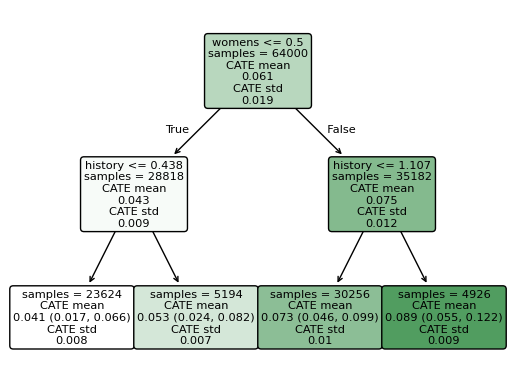

In [20]:
# 각 leaf는 서로 다른 방식으로 개입에 반응하는(subgroup-level heterogeneity) 하위 집단을 나타냄.
# 이를 통해 왜 효과가 달라지는지를 설명할 수 있다. 

intrp = SingleTreeCateInterpreter(include_model_uncertainty=True, max_depth=2, min_samples_leaf=10)
intrp.interpret(est, X)
intrp.plot(feature_names=list(data['feature_names']))

Interpretation: 
- 루트 노드: 조건: womens == 0, 여성 카테고리에 관심이 없는 고객은 이메일을 받으면, 이메일을 받지 않은 유사 고객에 비해 +6.1%p 상승


- womens == 0 그룹: 과거 구매력이 0.438 이하에 속하는지 여부
    - 속하지 않으면: 해당 특성을 가지지 않은 고객이 이메일을 받으면, 이메일을 받지 않은 유사 고객에 비해 +4.1%p 상승
    - 속하면: 해당 특성을 가진 고객이 이메일을 받으면, 이메일을 받지 않은 유사 고객에 비해 +5.3%p 상승


- womens == 1 그룹: 과거 구매력이 1.107 이하에 속하는지 여부
    - 속하지 않으면: 해당 특성을 가지지 않은 고객이 이메일을 받으면, 이메일을 받지 않은 유사 고객에 비해 +7.3%p 상승
    - 속하면: 해당 특성을 가진 고객이 이메일을 받으면, 이메일을 받지 않은 유사 고객에 비해 +8.9%p 상승

결론: 이메일 마케팅 uplift의 가장 큰 결정 요인은 여성 카테고리 관심 여부(womens 변수)이며, 트리 마지막 leaf 기준으로 가장 uplift가 높은 그룹은 womens == 1 AND history > 1.107이다.

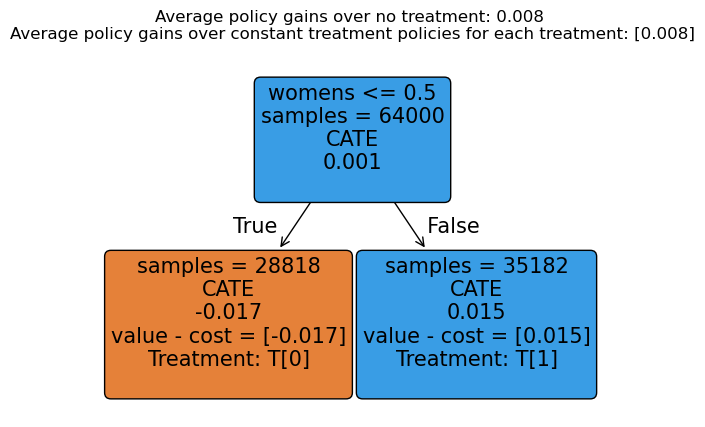

In [21]:
# Policy Interpreter는 데이터에서 처치 (이메일)를 받는 것이 유리한 사람과 불리한 사람을 분리하는 트리를 학습한다.
# 특히 정책의 '비용'을 설정할 수 있으며, 이를 통해 누구에게 treatment를 해야 이득인지 결정할 수 있다.

intrp = SingleTreePolicyInterpreter(
    max_depth=3,
    min_samples_leaf=500,
    min_impurity_decrease=1e-5,
    random_state=42
)
intrp.interpret(est, X,  sample_treatment_costs=0.06)
intrp.plot(feature_names=list(data['feature_names']))

방문 확률이 +6%p 이상 올라가는 고객에게만 이메일을 보내는 게 경제적으로 의미 있다고 가정한다면:

- 전혀 이메일을 보내지 않는 것보다 평균 방문 확률이 0.8%p 증가
- “여성 카테고리에 관심 없는 고객”에게는 이메일을 보내면 오히려 방문률이 1.7%p 감소
- “여성 카테고리에 관심 있는 고객”에게는 이메일을 보내면 오히려 방문률이 1.5%p 증가

=> 여성 카테고리에 관심 있는 고객에게 이메일을 보내는 것이 권장된다.


### Feature Importance / Permutation importance

- Feature importance는 해당 모델 (여기서는 트리)에서 얼마나 자주 분할 기준으로 사용됐는가를 의미하며, Permutation importance는 섞었을 때 예측이 얼마나 망가지는가를 의미한다.

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_squared_error

<Axes: xlabel='importance', ylabel='feature'>

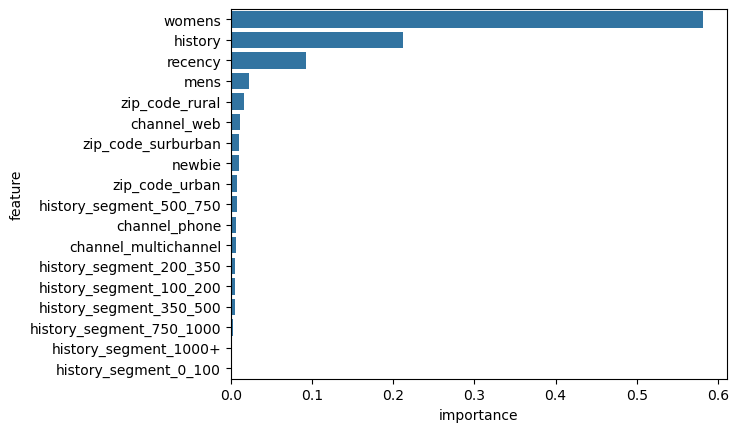

In [32]:
fi = est.feature_importances_

fi_df = pd.DataFrame({
    "feature": X_df.columns,
    "importance": fi
}).sort_values("importance", ascending=False)

sns.barplot(x='importance',y='feature',data=fi_df)

[해석 결과]

1. 여성 타겟 여부가 이메일 처치 효과의 이질성을 가장 강하게 결정한다.
2. 과거 구매 이력은 이메일 효과를 구분하는 핵심 연속형 변수이며, 구매 이력이 많은 고객과 적은 고객 사이에서 효과 차이가 뚜렷하다.

In [28]:
tau_hat = est.effect(X)


def permutation_importance_cate(
    est, X, tau_ref, n_repeats=5, random_state=42
):
    rng = np.random.RandomState(random_state)
    importances = []

    for j in range(X.shape[1]):
        losses = []

        for _ in range(n_repeats):
            X_perm = X.copy()
            rng.shuffle(X_perm[:, j])

            tau_perm = est.effect(X_perm)
            loss = mean_squared_error(tau_ref, tau_perm)
            losses.append(loss)

        importances.append(np.mean(losses))

    return np.array(importances)

In [29]:
perm_imp = permutation_importance_cate(
    est,
    X,
    tau_hat,
    n_repeats=5
)

perm_df = pd.DataFrame({
    "feature": X_df.columns,
    "perm_importance": perm_imp
}).sort_values("perm_importance", ascending=False)

perm_df

,feature,perm_importance
3,womens,8.236541e-04
1,history,1.436563e-04
2,mens,1.056059e-04
0,recency,6.466865e-05
5,zip_code_rural,1.008519e-05
4,newbie,9.412965e-06
17,channel_web,5.177159e-06
7,zip_code_urban,4.063373e-06
6,zip_code_surburban,3.271713e-06
16,channel_phone,2.262342e-06


[해석 결과]

1. 여성 타겟 여부는 섞는 순간, CATE 예측이 가장 크게 무너진다.
2. 과거 구매 이력은 성별 다음으로 중요한 효과 조절 변수이며, 고객의 반응 강도를 연속적으로 조절하는 역할을 한다.
3. 남성 관련 관심 변수 역시 효과 차이를 만드는 데 기여한다.

### SHAP

위의 Feature Imporatnce나 Permutation importance과 달리, SHAP은 개인별로 원인을 설명할 수 있으며, 그리고 각 변수의 방향성에 대해 설명할 수 있다.

---

기존 SHAP 분석과 동일하나, 여기서 SHAP의 목표는 outcome 예측에 기여하는 변수가 아닌,
처치 반응성을 변화시키는 변수 (Effect Modifiers)라는 것에 주의하여 해석할 수 있다.

출처:

- https://www.pywhy.org/EconML/spec/interpretability.html#shap
- https://shap.readthedocs.io/en/latest/api.html#explainers

#### Individual

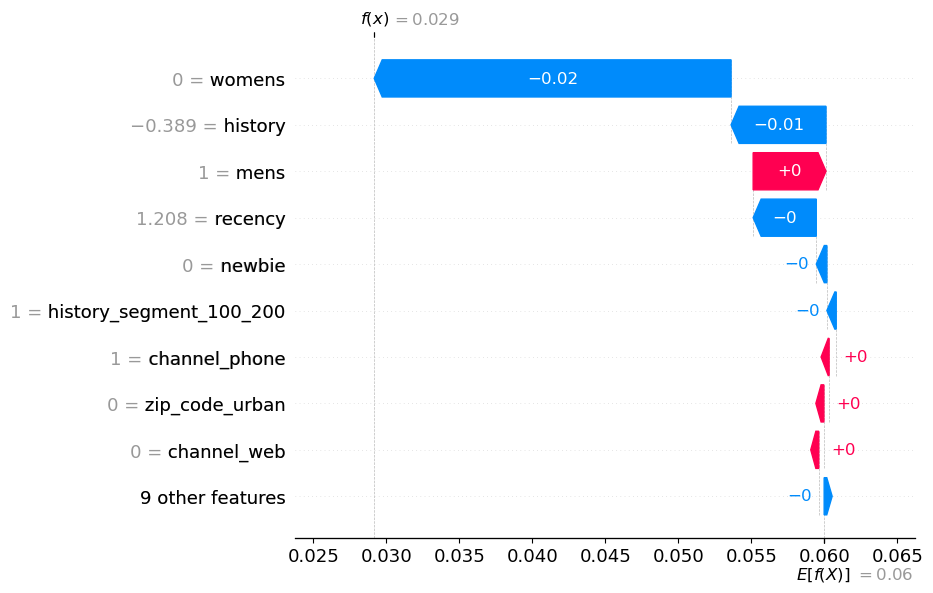

In [22]:
import shap

# 묘사를 위해 100개의 샘플에서만 모델을 돌림.

ind = 0
X_bg = X[ind:ind+100]

shap_values = est.shap_values(X_bg)

exp = shap_values["Y0"]["T0"]
exp.feature_names = X_df.columns.tolist()
exp.data = X_bg

shap.plots.waterfall(exp[0])

1. Average Treatment Effect (Base Value): 0.06

2. Estimated CATE for this individual: 0.029

3. 부정적으로 영향을 미친 요인
    - womens == 0 : 여성 고객이 아닌 경우
    - history: 구매 이력이 적어지는 경우



#### Global

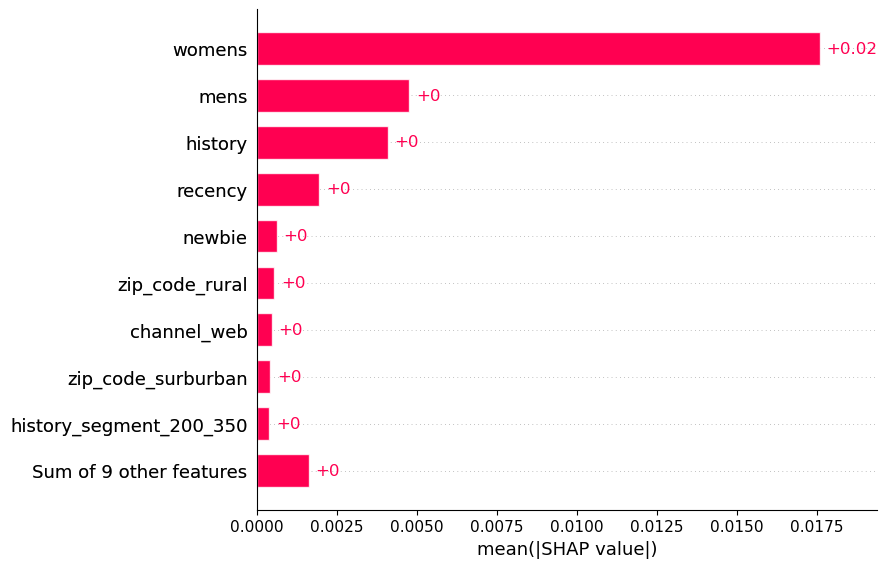

In [23]:
shap.plots.bar(exp)

[해석 결과]

- 전체적으로 어떤 변수가 처치 효과 차이를 가장 많이 만들어내는가를 해석할 수 있는 Bar Plot
    - womens, mens 등의 성별 변수가 큰 영향을 미침. 

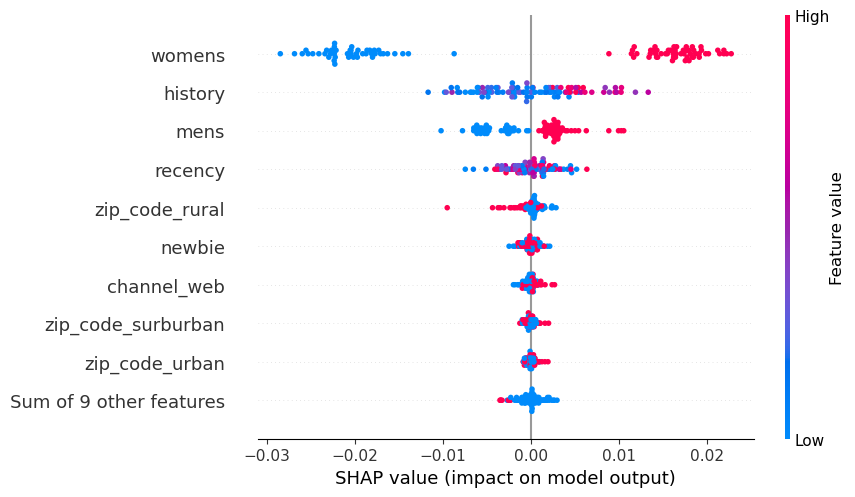

In [25]:
# 묘사를 위해 100개의 샘플에서만 모델을 돌림.

np.random.seed(42)
idx = np.random.choice(X.shape[0], size=100, replace=False)
X_shap = X[idx]

shap_values = est.shap_values(X_shap)
exp = shap_values["Y0"]["T0"]

exp.data = X_shap
exp.feature_names = X_df.columns.tolist()

shap.plots.beeswarm(exp)


[해석결과]

1. 여성 타겟 제품 관심 고객일수록 처치 효과가 증가. (여성 타겟 제품 관심 고객이 아닌 경우 처치 효과가 감소)
2. 구매 이력이 적은 고객일수록 처치 반응성이 크다. (다만 같은 세그먼트 내에서도 개인별 효과 차이가 존재한다.)
3. 남성 타겟 제품 관심 고객일수록 이메일 처치 효과가 상대적으로 높다.